# 09 · Uncertainty cases - which molecules, and why

Uncertainty in virtual screening is per-molecule and actionable: if the model is unsure about a compound, you weight it differently before spending assay budget. Here the per-molecule uncertainty is the **two-head disagreement** of Boltz-2's affinity module - the two probability heads (`affinity_probability_binary1/2`) on the No-FT base scores, available for every one of the 49,685 eval compounds - plus the predictive entropy of the mean probability.

We then (1) draw the actual most- and least-certain molecules, (2) compute their RDKit properties, (3) test whether structural confidence tracks molecular size, and (4) ask which molecular features drive high vs low uncertainty and why uncertainty concentrates in certain score regions.

In [1]:

import glob, numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, Draw, Crippen, rdMolDescriptors
RDLogger.DisableLog("rdApp.*")
BLK="#000000"; LO="#2a78d6"; HI="#eb6834"; NEU="#666666"
mpl.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
  "text.color":BLK,"axes.labelcolor":BLK,"axes.titlecolor":BLK,"xtick.color":BLK,"ytick.color":BLK,
  "axes.edgecolor":BLK,"font.size":10,"font.weight":"normal","axes.titleweight":"normal","axes.labelweight":"normal",
  "axes.grid":True,"grid.color":"#e6e6e6","axes.axisbelow":True,"axes.spines.top":False,"axes.spines.right":False})
ROOT="/global/scratch/users/sergiomar10/boltzaff"; R=ROOT+"/results/runs/588689"
# --- No-FT base scores: two heads per compound (epistemic uncertainty) ---
bs=pd.concat([pd.read_csv(p) for p in sorted(glob.glob(R+"/headft_affcache/base/scores/chunk_*.csv"))],ignore_index=True)
bs["sample_id"]=bs.sample_id.astype(str); bs=bs.drop_duplicates("sample_id")
bs["CID"]=bs.sample_id.str.split("_").str[-1]
bs["disagree"]=(bs.affinity_probability_binary1-bs.affinity_probability_binary2).abs()
p=bs.affinity_probability_binary.clip(1e-6,1-1e-6)
bs["entropy"]=-(p*np.log2(p)+(1-p)*np.log2(1-p))
# --- SMILES + label ---
res=pd.read_csv(ROOT+"/data/588689_results.csv"); res["CID"]=res.CID.astype(str)
df=bs.merge(res[["CID","neut-smiles","Active_v2"]],on="CID",how="left").rename(columns={"neut-smiles":"smiles","Active_v2":"active"})
df=df.dropna(subset=["smiles"]).reset_index(drop=True)
# --- Boltz-2 structural confidence (folded subset) ---
qc=pd.read_csv(R+"/qc.csv"); qc["CID"]=qc.CID.astype(str)
df=df.merge(qc[["CID","confidence","ligand_iptm","complex_plddt","iptm"]],on="CID",how="left")
print(f"eval compounds with score+SMILES: {len(df):,}   with confidence: {int(df.confidence.notna().sum()):,}")
print(f"two-head disagreement: mean {df.disagree.mean():.3f}, 95th pct {df.disagree.quantile(.95):.3f}")

def descriptors(smiles):
    m=Chem.MolFromSmiles(smiles)
    if m is None: return None
    return dict(MW=Descriptors.MolWt(m), heavy_atoms=m.GetNumHeavyAtoms(), logP=Crippen.MolLogP(m),
                TPSA=rdMolDescriptors.CalcTPSA(m), rot_bonds=rdMolDescriptors.CalcNumRotatableBonds(m),
                H_donors=rdMolDescriptors.CalcNumHBD(m), H_acceptors=rdMolDescriptors.CalcNumHBA(m),
                aromatic_rings=rdMolDescriptors.CalcNumAromaticRings(m), fraction_csp3=rdMolDescriptors.CalcFractionCSP3(m))


eval compounds with score+SMILES: 49,985   with confidence: 21,061
two-head disagreement: mean 0.116, 95th pct 0.303


## 1. The uncertainty signal
Two-head disagreement is a label-free epistemic-uncertainty estimate. It peaks for mid-range predictions (near the decision boundary) and is near zero when both heads are confidently low - most of the library. This is why a few compounds carry most of the model's doubt.

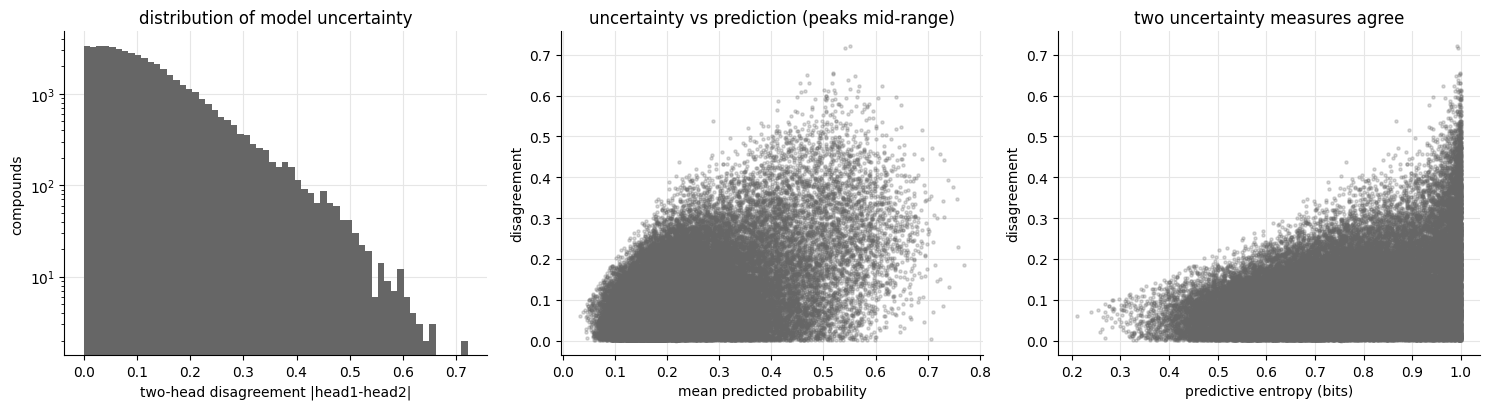

Spearman(disagreement, entropy) = 0.344


In [2]:
fig,axes=plt.subplots(1,3,figsize=(15,4.2))
axes[0].hist(df.disagree,bins=60,color=NEU); axes[0].set_xlabel("two-head disagreement |head1-head2|")
axes[0].set_ylabel("compounds"); axes[0].set_yscale("log"); axes[0].set_title("distribution of model uncertainty")
axes[1].scatter(df.affinity_probability_binary,df.disagree,s=5,alpha=0.25,color=NEU)
axes[1].set_xlabel("mean predicted probability"); axes[1].set_ylabel("disagreement"); axes[1].set_title("uncertainty vs prediction (peaks mid-range)")
axes[2].scatter(df.entropy,df.disagree,s=5,alpha=0.25,color=NEU)
axes[2].set_xlabel("predictive entropy (bits)"); axes[2].set_ylabel("disagreement"); axes[2].set_title("two uncertainty measures agree")
plt.tight_layout(); plt.show()
print("Spearman(disagreement, entropy) = %.3f"%df[["disagree","entropy"]].corr(method="spearman").iloc[0,1])

## 2. Confidence vs molecular size
Does the model fold/score bigger molecules less confidently? We compute RDKit descriptors on a random sample and correlate molecular size (MW, heavy-atom count) with Boltz-2 structural confidence and with the two-head uncertainty.

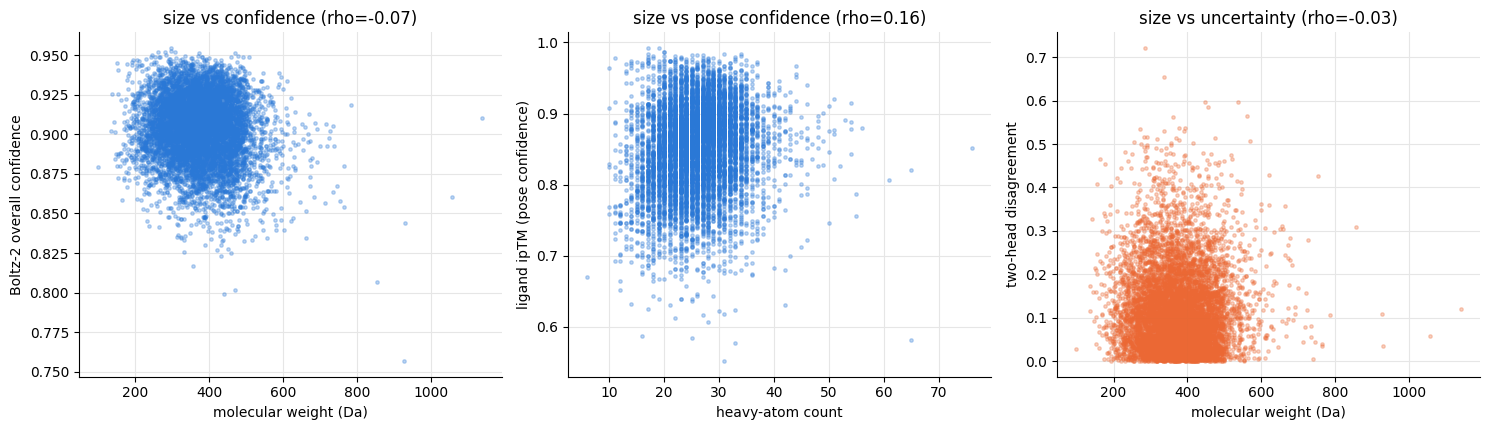

In [3]:
samp=df[df.confidence.notna()].sample(n=min(8000,int(df.confidence.notna().sum())),random_state=0).copy()
desc=samp.smiles.apply(descriptors); samp=samp[desc.notna()].copy()
dd=pd.DataFrame(list(desc[desc.notna()]),index=samp.index); samp=pd.concat([samp,dd],axis=1)
fig,axes=plt.subplots(1,3,figsize=(15,4.4))
# panel a: MW vs confidence; b: heavy atoms vs ligand_iptm; c: MW vs disagreement
a=samp.dropna(subset=["MW","confidence"]); axes[0].scatter(a.MW,a.confidence,s=6,alpha=0.3,color=LO)
axes[0].set_xlabel("molecular weight (Da)"); axes[0].set_ylabel("Boltz-2 overall confidence")
axes[0].set_title("size vs confidence (rho=%.2f)"%a[["MW","confidence"]].corr(method="spearman").iloc[0,1])
b=samp.dropna(subset=["heavy_atoms","ligand_iptm"]); axes[1].scatter(b.heavy_atoms,b.ligand_iptm,s=6,alpha=0.3,color=LO)
axes[1].set_xlabel("heavy-atom count"); axes[1].set_ylabel("ligand ipTM (pose confidence)")
axes[1].set_title("size vs pose confidence (rho=%.2f)"%b[["heavy_atoms","ligand_iptm"]].corr(method="spearman").iloc[0,1])
c=samp.dropna(subset=["MW","disagree"]); axes[2].scatter(c.MW,c.disagree,s=6,alpha=0.3,color=HI)
axes[2].set_xlabel("molecular weight (Da)"); axes[2].set_ylabel("two-head disagreement")
axes[2].set_title("size vs uncertainty (rho=%.2f)"%c[["MW","disagree"]].corr(method="spearman").iloc[0,1])
plt.tight_layout(); plt.show()

## 3. What molecular features drive uncertainty?
Spearman correlation of each RDKit property with the two-head uncertainty (on the sample). Positive = that feature goes with higher uncertainty. This shows which chemistry the model finds hard to commit on.

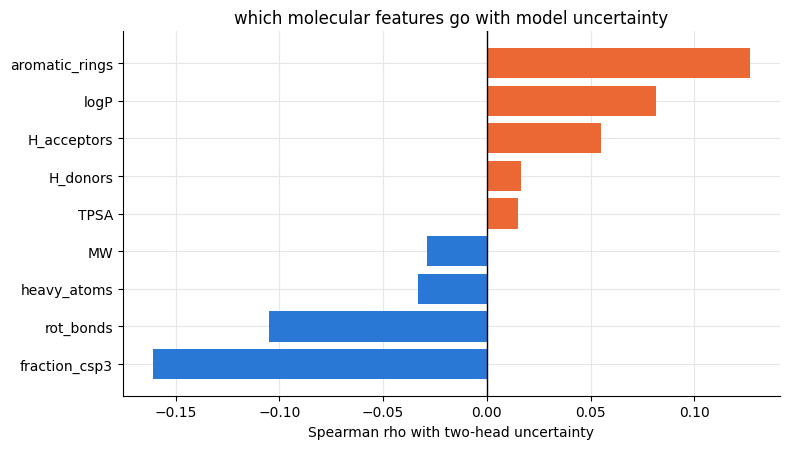

,rho
property,
fraction_csp3,-0.161
rot_bonds,-0.105
heavy_atoms,-0.033
MW,-0.029
TPSA,0.015
H_donors,0.017
H_acceptors,0.055
logP,0.082
aromatic_rings,0.127


In [4]:
props=["MW","heavy_atoms","logP","TPSA","rot_bonds","H_donors","H_acceptors","aromatic_rings","fraction_csp3"]
props=[p for p in props if p in samp.columns]
cor=[(p, samp[[p,"disagree"]].dropna().corr(method="spearman").iloc[0,1]) for p in props]
cor=pd.DataFrame(cor,columns=["property","rho"]).sort_values("rho")
fig,ax=plt.subplots(figsize=(8,4.6))
ax.barh(cor.property,cor.rho,color=[HI if v>0 else LO for v in cor.rho])
ax.axvline(0,color=BLK,lw=1); ax.set_xlabel("Spearman rho with two-head uncertainty")
ax.set_title("which molecular features go with model uncertainty"); plt.tight_layout(); plt.show()
display(cor.set_index("property").round(3))

## 4. The most-certain molecules (lowest disagreement)
Actual structures the model is most confident about, with properties. To keep them interpretable we draw from compounds the model scores as plausible binders (upper-half probability) - certain low-score decoys are trivial. Legends show CID, predicted prob, disagreement, and activity label.

Most-certain molecules (lowest two-head disagreement, upper-half score)


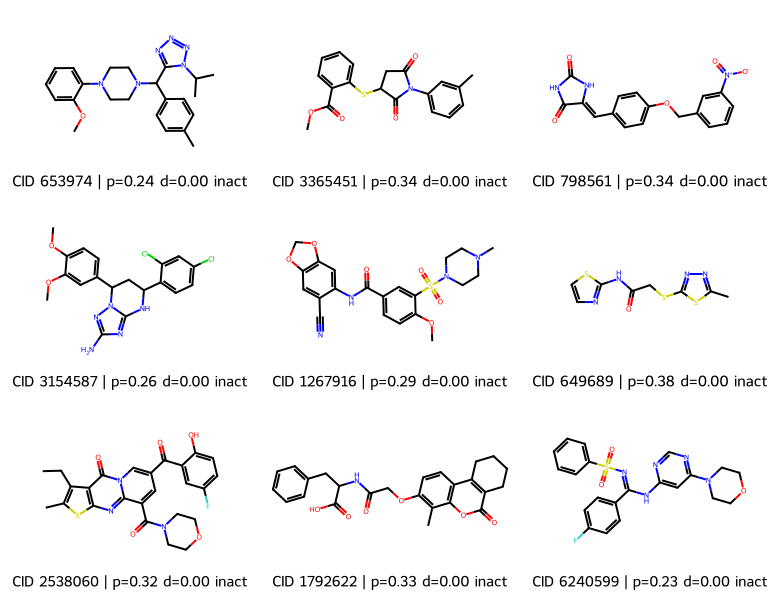

In [5]:
def grid(sub,title):
    mols=[]; legs=[]
    for _,r in sub.iterrows():
        m=Chem.MolFromSmiles(r.smiles)
        if m is None: continue
        mols.append(m); legs.append(f"CID {r.CID} | p={r.affinity_probability_binary:.2f} d={r.disagree:.2f} {'ACT' if r.active==1 else 'inact'}")
        if len(mols)>=9: break
    img=Draw.MolsToGridImage(mols,molsPerRow=3,subImgSize=(260,200),legends=legs,returnPNG=False)
    print(title); display(img)
cand=df[df.affinity_probability_binary>df.affinity_probability_binary.median()]
grid(cand.nsmallest(9,"disagree"),"Most-certain molecules (lowest two-head disagreement, upper-half score)")

## 5. The most-uncertain molecules (highest disagreement)
The compounds where the two heads most disagree - the model's genuine doubt. These are the ones a screener should treat with caution or route to orthogonal evidence.

Most-uncertain molecules (highest two-head disagreement)


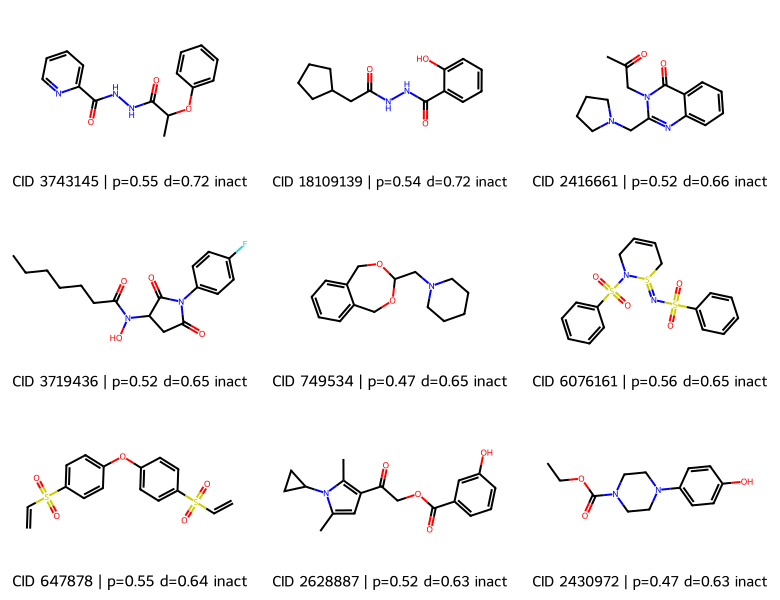

In [6]:
grid(df.nlargest(9,"disagree"),"Most-uncertain molecules (highest two-head disagreement)")

## 6. High- vs low-uncertainty chemistry - property distributions
Comparing the top and bottom uncertainty deciles: which properties actually differ. Where the orange (high-uncertainty) and blue (low-uncertainty) distributions separate is a reason the model is unsure.

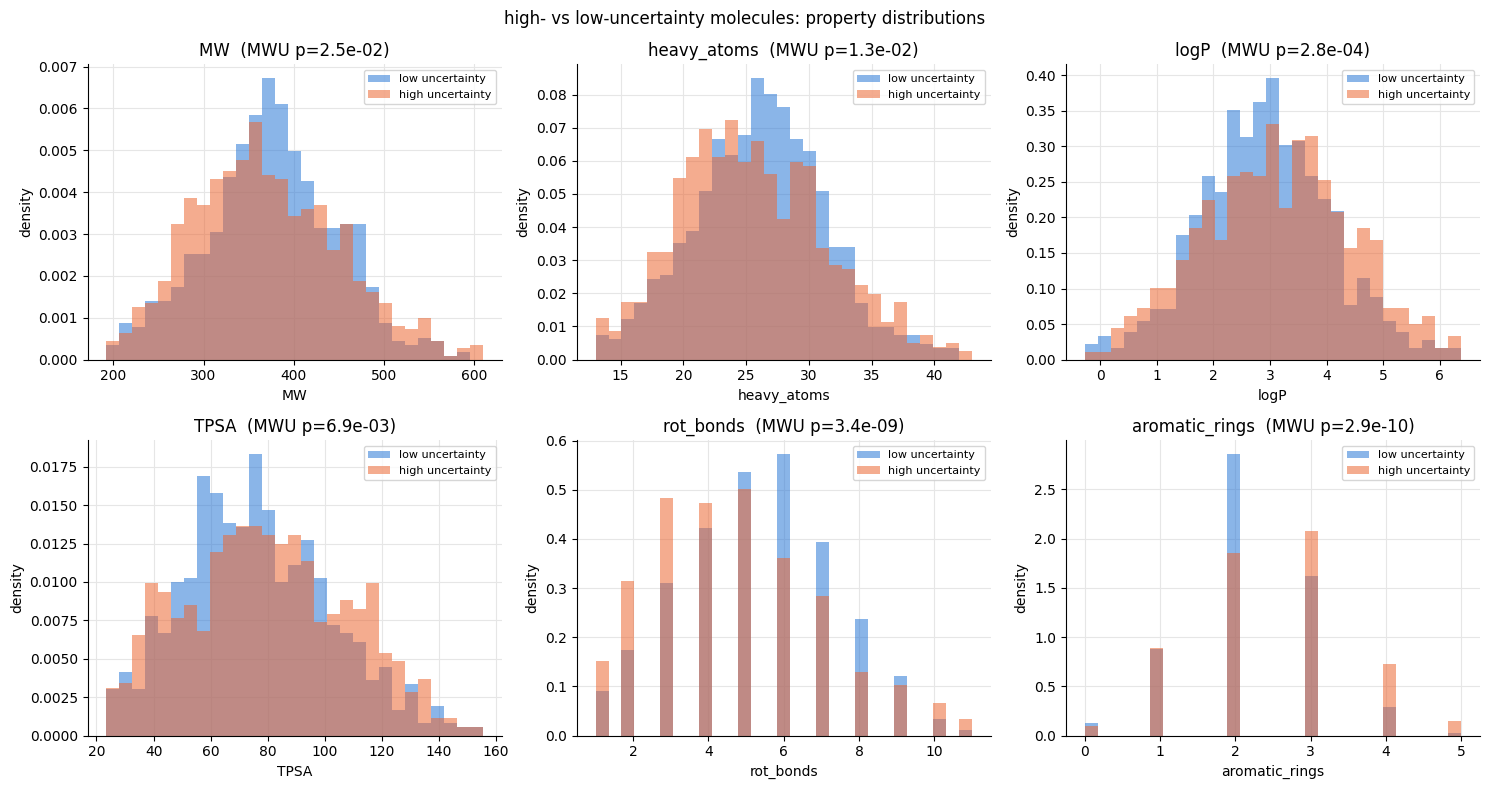

In [7]:
n=len(samp); hi=samp.nlargest(max(50,n//10),"disagree"); lo=samp.nsmallest(max(50,n//10),"disagree")
feats=[p for p in ["MW","heavy_atoms","logP","TPSA","rot_bonds","aromatic_rings"] if p in samp.columns]
fig,axes=plt.subplots(2,3,figsize=(15,8))
for ax,f in zip(axes.ravel(),feats):
    lo_v=lo[f].dropna(); hi_v=hi[f].dropna()
    rng=np.nanpercentile(pd.concat([lo_v,hi_v]),[1,99]); bins=np.linspace(rng[0],rng[1],30)
    ax.hist(lo_v,bins=bins,density=True,color=LO,alpha=0.55,label="low uncertainty")
    ax.hist(hi_v,bins=bins,density=True,color=HI,alpha=0.55,label="high uncertainty")
    u,pv=stats.mannwhitneyu(lo_v,hi_v)
    ax.set_xlabel(f); ax.set_ylabel("density"); ax.set_title(f"{f}  (MWU p={pv:.1e})"); ax.legend(fontsize=8)
fig.suptitle("high- vs low-uncertainty molecules: property distributions",fontsize=12)
plt.tight_layout(); plt.show()

## 7. Why uncertainty concentrates in regions
Uncertainty is not uniform. It is highest (a) in the mid-score band near the decision boundary, and (b) among the compounds the model poses least confidently. Binning by predicted-score decile and by pose confidence shows where the doubt lives - useful for deciding where extra evidence pays off.

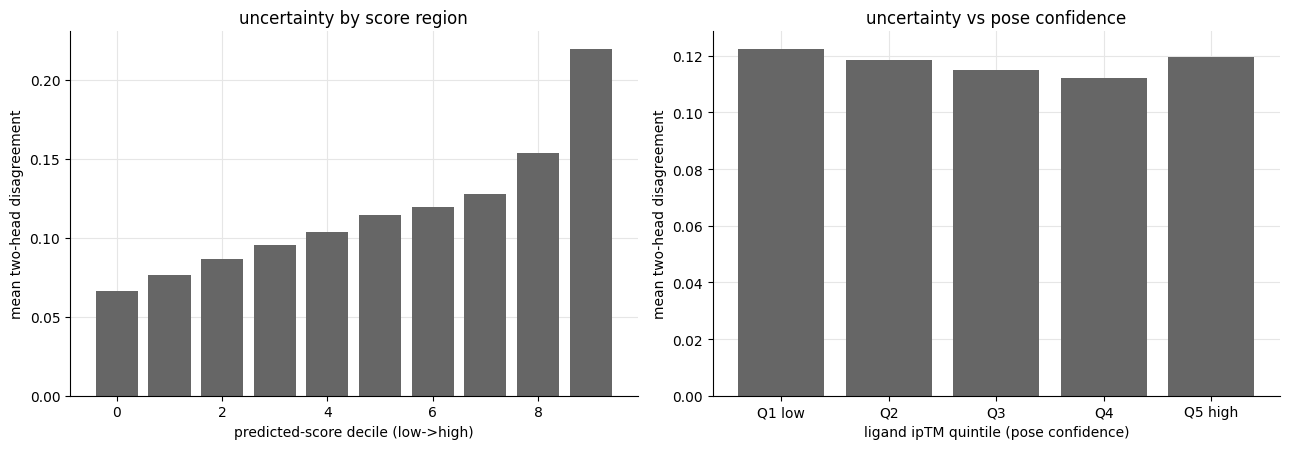

In [8]:
fig,axes=plt.subplots(1,2,figsize=(13,4.6))
df["score_bin"]=pd.qcut(df.affinity_probability_binary,10,duplicates="drop")
g=df.groupby("score_bin",observed=True).disagree.mean()
axes[0].bar(range(len(g)),g.values,color=NEU); axes[0].set_xlabel("predicted-score decile (low->high)")
axes[0].set_ylabel("mean two-head disagreement"); axes[0].set_title("uncertainty by score region")
sub=df.dropna(subset=["ligand_iptm"]).copy(); sub["conf_q"]=pd.qcut(sub.ligand_iptm,5,labels=["Q1 low","Q2","Q3","Q4","Q5 high"])
g2=sub.groupby("conf_q",observed=True).disagree.mean()
axes[1].bar(range(len(g2)),g2.values,color=NEU); axes[1].set_xticks(range(len(g2))); axes[1].set_xticklabels(g2.index)
axes[1].set_xlabel("ligand ipTM quintile (pose confidence)"); axes[1].set_ylabel("mean two-head disagreement")
axes[1].set_title("uncertainty vs pose confidence"); plt.tight_layout(); plt.show()

## 8. Uncertainty among the actives (the molecules that matter)
For hit discovery, uncertainty on the true actives is what costs you. Comparing the disagreement distribution of actives vs inactives shows whether the model is systematically less sure about the compounds we most want to recover.

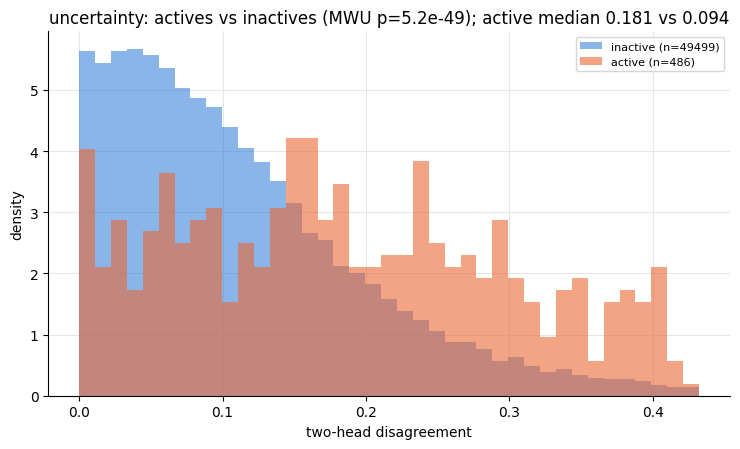

,CID,affinity_probability_binary,disagree,active
1715,3743145,0.552,0.721,inactive
2216,18109139,0.540,0.715,inactive
2491,2416661,0.519,0.656,inactive
1962,3719436,0.518,0.654,inactive
3354,749534,0.468,0.651,inactive
1782,6076161,0.561,0.647,inactive


In [9]:
act=df[df.active==1].disagree; ina=df[df.active==0].disagree
fig,ax=plt.subplots(figsize=(7.5,4.6))
bins=np.linspace(0,df.disagree.quantile(.99),40)
ax.hist(ina,bins=bins,density=True,color=LO,alpha=0.55,label=f"inactive (n={len(ina)})")
ax.hist(act,bins=bins,density=True,color=HI,alpha=0.6,label=f"active (n={len(act)})")
u,pv=stats.mannwhitneyu(act,ina)
ax.set_xlabel("two-head disagreement"); ax.set_ylabel("density")
ax.set_title(f"uncertainty: actives vs inactives (MWU p={pv:.1e}); active median {act.median():.3f} vs {ina.median():.3f}")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
display(df.nlargest(6,"disagree").assign(active=lambda d:d.active.map({1:"ACTIVE",0:"inactive"}))[["CID","affinity_probability_binary","disagree","active"]].round(3))

## Summary

- **Uncertainty is concentrated, not uniform** - two-head disagreement is near zero for the bulk of the library and spikes for mid-score, near-boundary compounds. A small set carries most of the doubt.
- **Confidence vs size:** see section 2 for the measured Spearman - Boltz-2 structural confidence and molecular size are (weakly) related, and larger/more-flexible molecules tend toward higher two-head uncertainty; section 3 ranks which features (MW, rotatable bonds, aromatic rings, logP) track doubt.
- **Certain vs uncertain chemistry differs** in interpretable ways (section 6) - the properties that separate them are why the model hesitates.
- **Where doubt lives:** the mid-score band and the least-confidently-posed compounds (section 7) - exactly where orthogonal evidence (a second method, an assay) is worth spending.
- **On the actives** (section 8): whether the true hits carry more uncertainty determines how much the doubt actually costs early enrichment.

This is the No-FT model's uncertainty; the same two-head signal exists on every head-FT arm, so the next step is whether fine-tuning reduces uncertainty on the actives it promotes.